# ML Lab


In [1]:
import pandas as pd
from pathlib import Path
import os

# --- loading data
def path_file():
    curr_dir=Path.cwd()
    # global df_path
    df_path=f"{curr_dir}/../data/df_LSTM.csv"
    if not os.path.exists:
        raise FileNotFoundError(f"File Not Found : {os.path.abspath(df_path)}")
    return df_path

def read_df():
    df_path=path_file()
    df=pd.read_csv(df_path)
    return df

df=read_df()        # datafile's name

# -> test data file loading
df.head(2)



,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30


In [2]:
print("=== info ===")
print(df.info())

=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54170 entries, 0 to 54169
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DateTime       54170 non-null  object
 1   Consumption    54170 non-null  int64 
 2   Production     54170 non-null  int64 
 3   Nuclear        54170 non-null  int64 
 4   Wind           54170 non-null  int64 
 5   Hydroelectric  54170 non-null  int64 
 6   Oil and Gas    54170 non-null  int64 
 7   Coal           54170 non-null  int64 
 8   Solar          54170 non-null  int64 
 9   Biomass        54170 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 4.1+ MB
None


In [3]:
print("=== Shape ===")
print(df.shape)

print("=== Description ===")
print(df.describe())

=== Shape ===
(54170, 10)
=== Description ===
        Consumption    Production       Nuclear          Wind  Hydroelectric  \
count  54170.000000  54170.000000  54170.000000  54170.000000   54170.000000   
mean    6526.463688   6380.179989   1282.480377    771.727691    1792.639616   
std     1048.248455   1015.393399    241.188791    666.534396     679.983743   
min     2922.000000   3119.000000    562.000000    -26.000000     175.000000   
25%     5710.000000   5639.000000   1341.000000    228.000000    1281.000000   
50%     6474.000000   6322.000000   1378.000000    571.000000    1679.000000   
75%     7268.000000   7057.750000   1400.000000   1167.000000    2191.000000   
max     9615.000000   9886.000000   1457.000000   2811.000000    4434.000000   

        Oil and Gas          Coal         Solar       Biomass  
count  54170.000000  54170.000000  54170.000000  54170.000000  
mean    1166.843696   1138.501052    171.808381     54.938859  
std      433.926493    329.928643    257.

## Visualisation de data
### DateTime : string --> timestamp


In [17]:
# --- date format : treatement
def convert_date():
    df_copy["DateTime"]=pd.to_datetime(df_copy["DateTime"])
    df_copy=df_copy.sort_values("DateTime")
    df_copy.set_index("DateTime", inplace=True)
    return df_copy["DateTime"]

df.head(2)
# print(df_copy["DateTime"].dtypes)   # -> Object


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30


### Line Plot (Serie Temporelle)

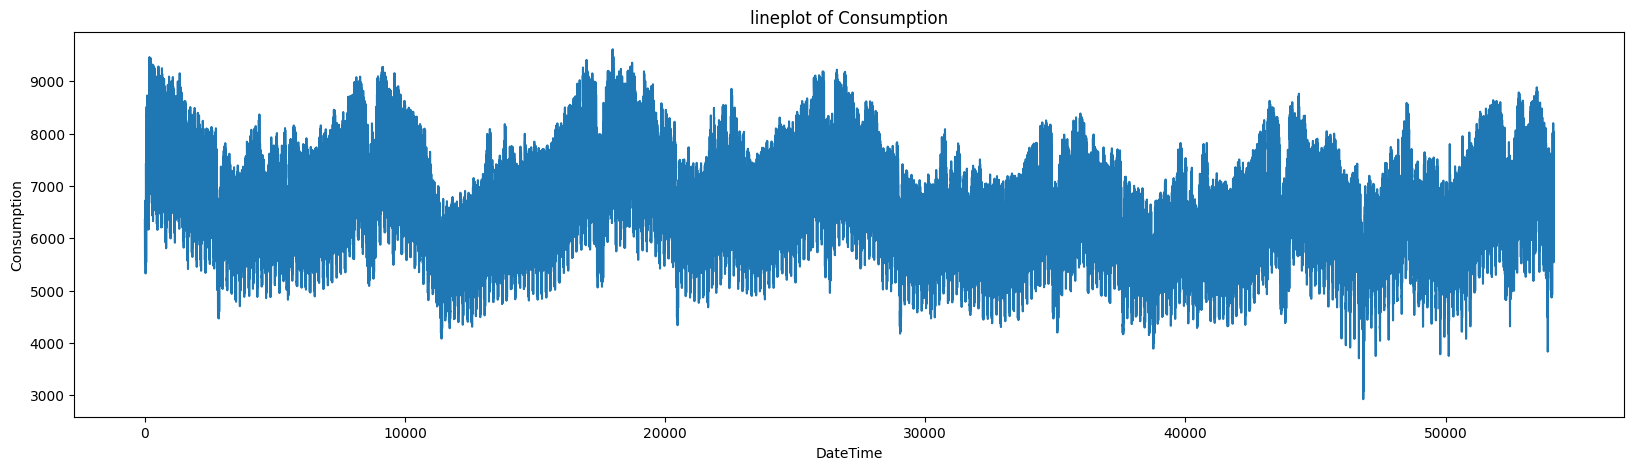

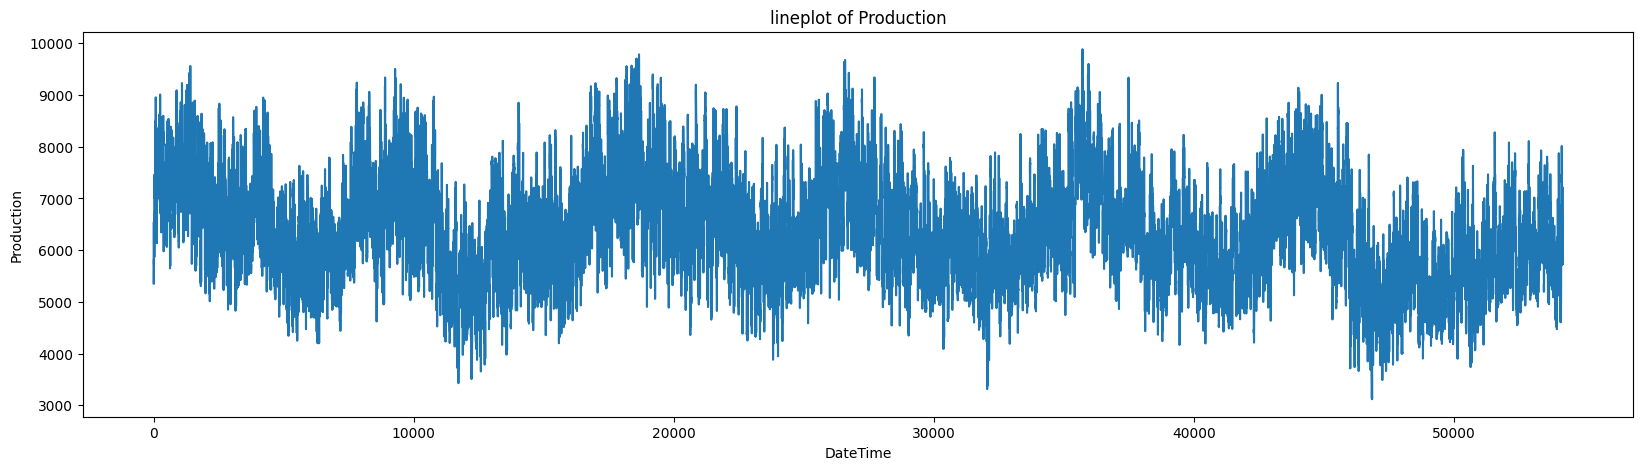

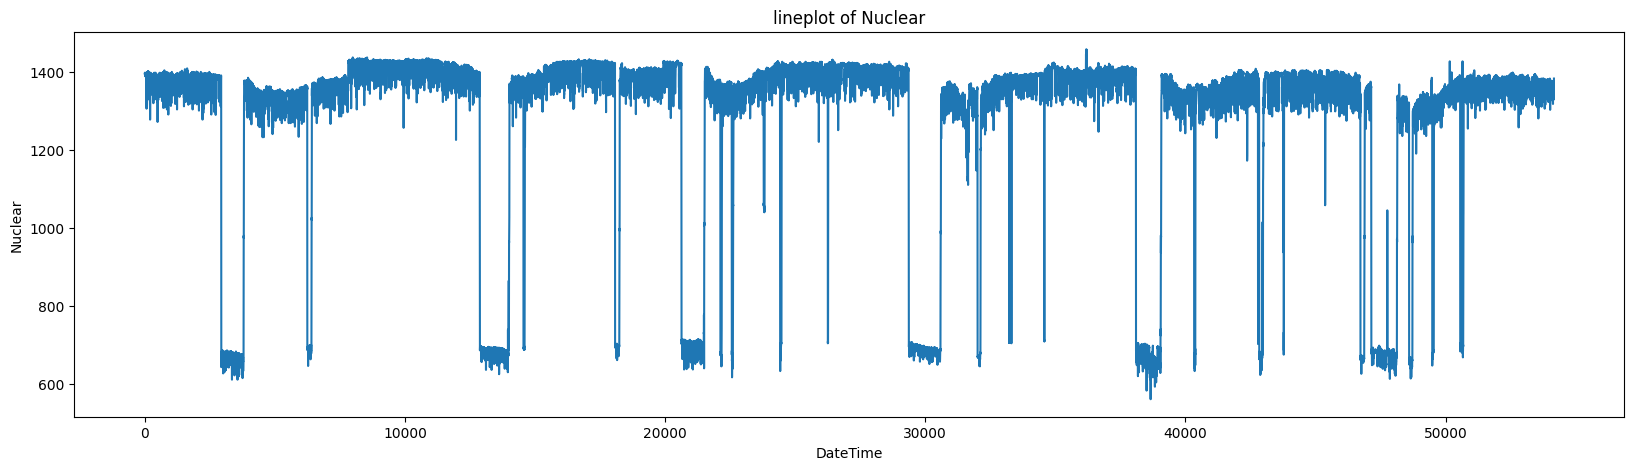

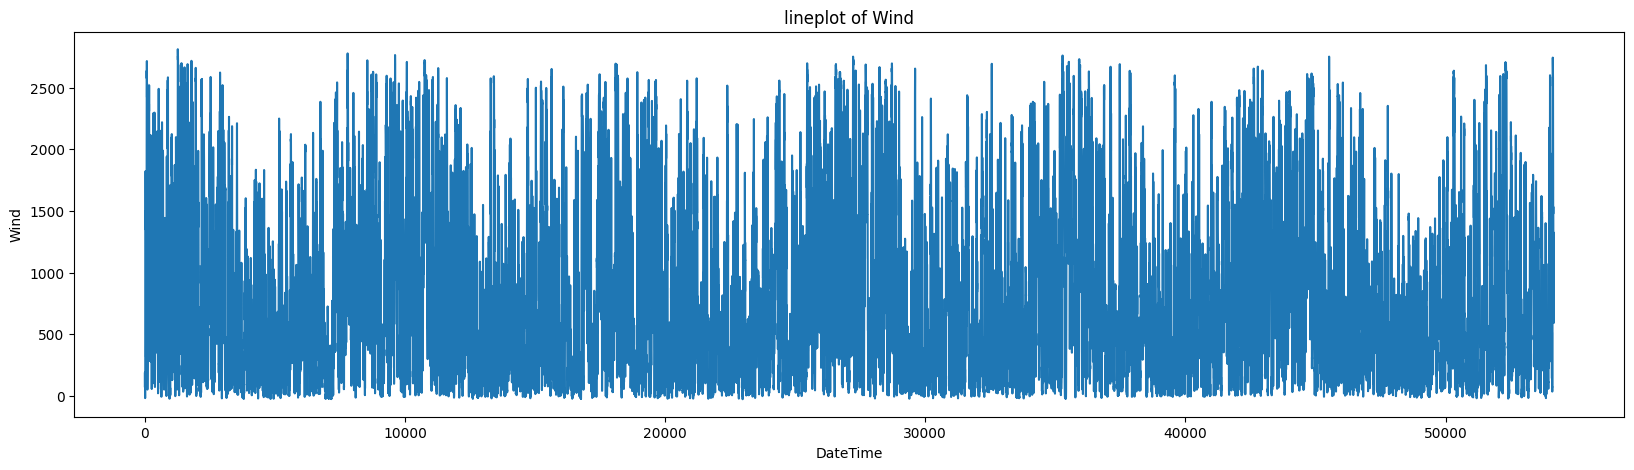

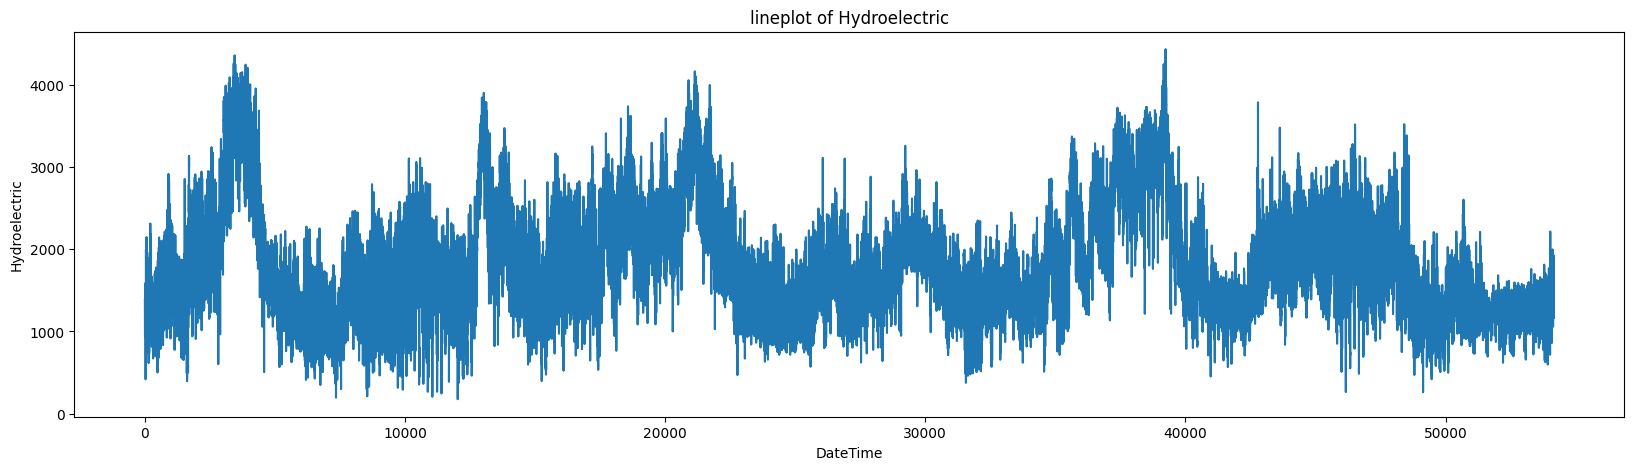

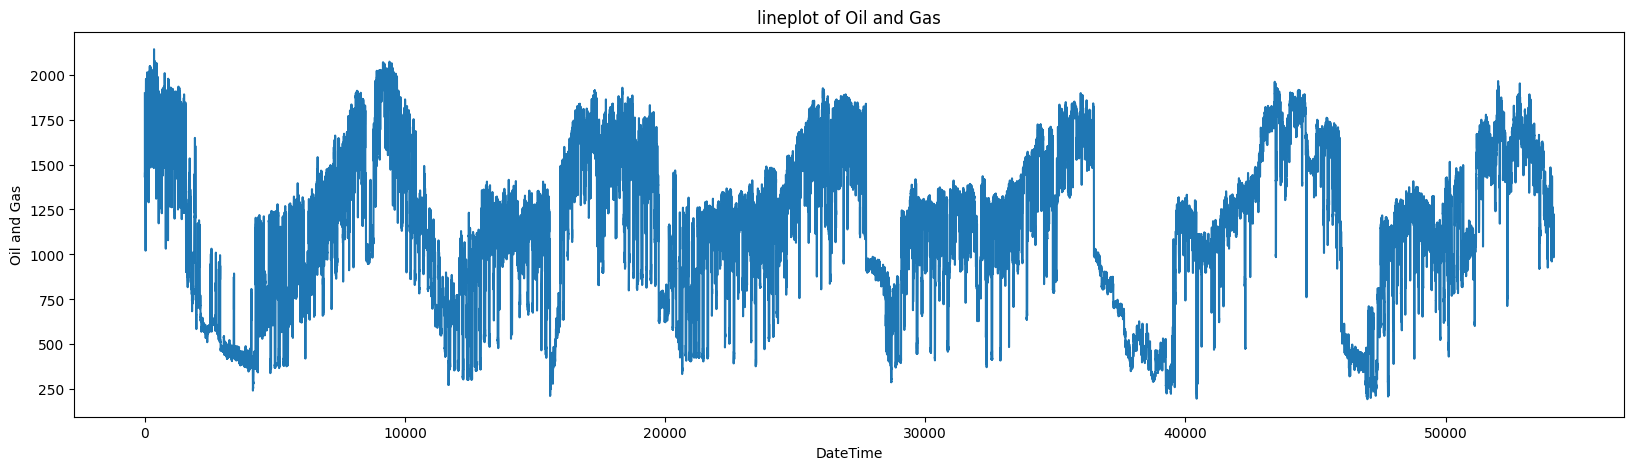

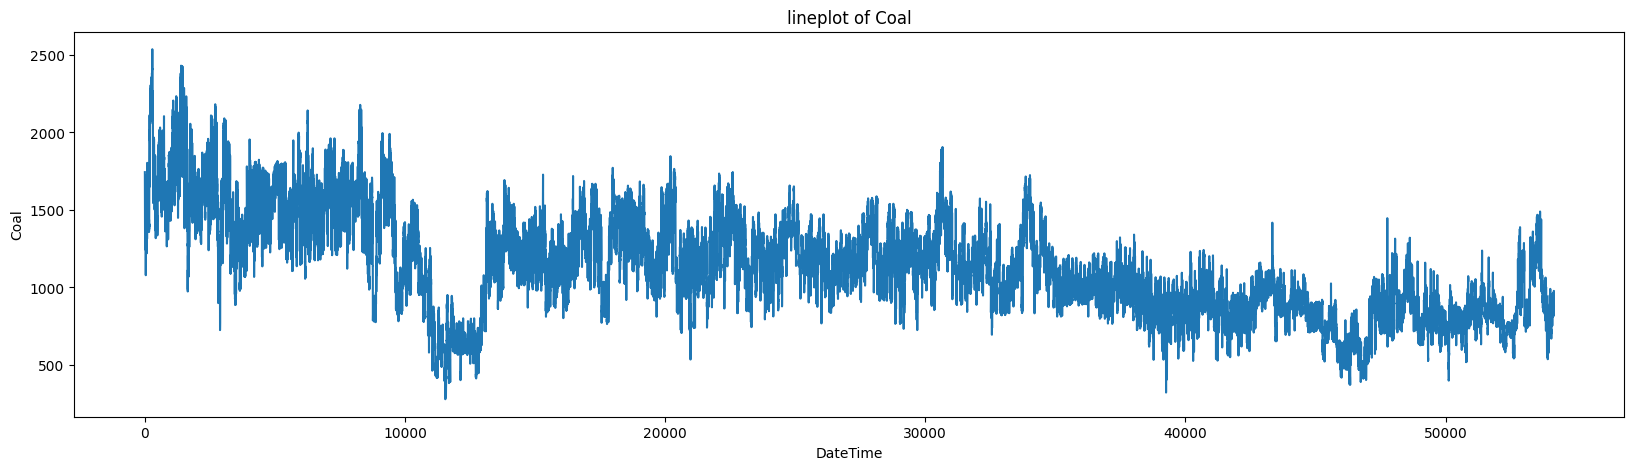

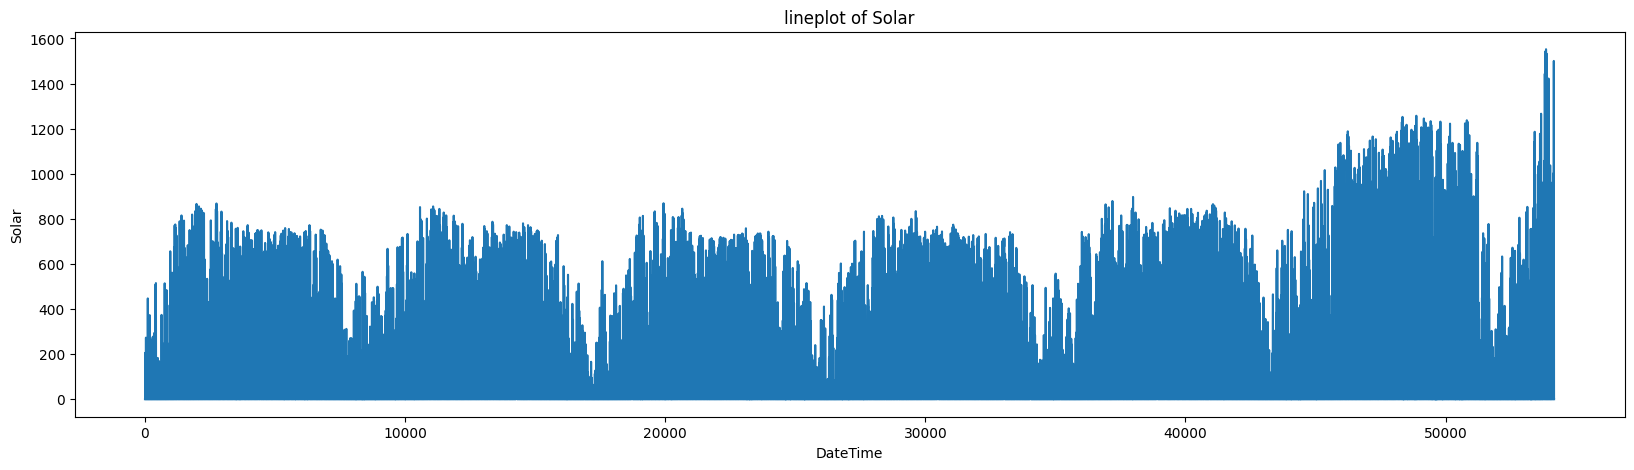

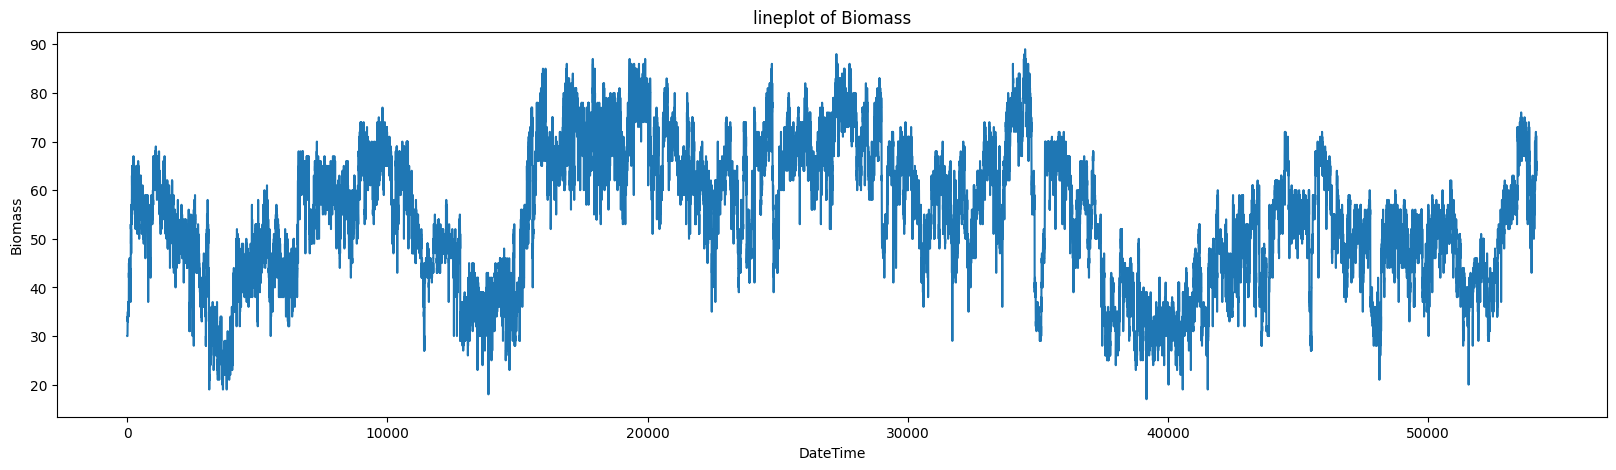

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_copy=df.copy()
# df_time=df_copy["DateTime"]
df_num=df_copy.select_dtypes(include=np.number)
df_num=df_num.groupby(df_num.index).mean()
for col in df_copy:
    if col == "DateTime":
        continue
    plt.figure(figsize=(20,5))
    sns.lineplot(data=df_copy, x=df_copy.index, y=col)
    plt.title(f"lineplot of {col}")
    plt.xlabel("DateTime") 
    plt.show()

### LinePlot : Affichage En Zoom 

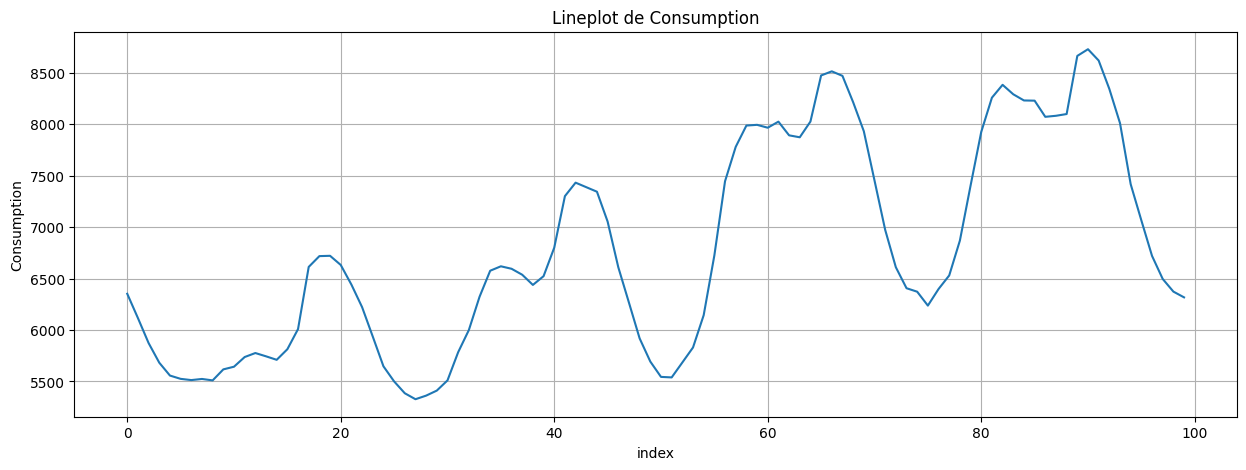

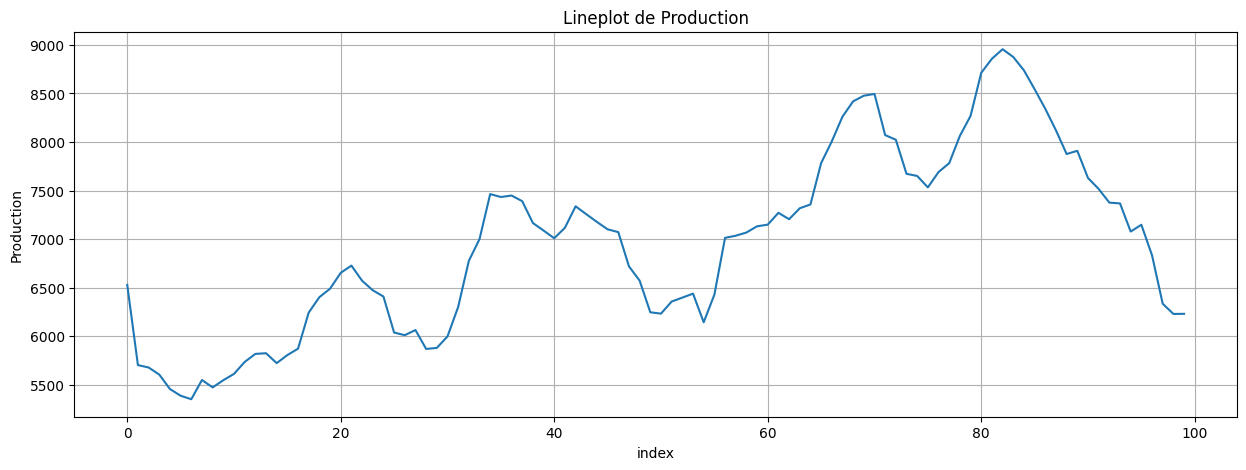

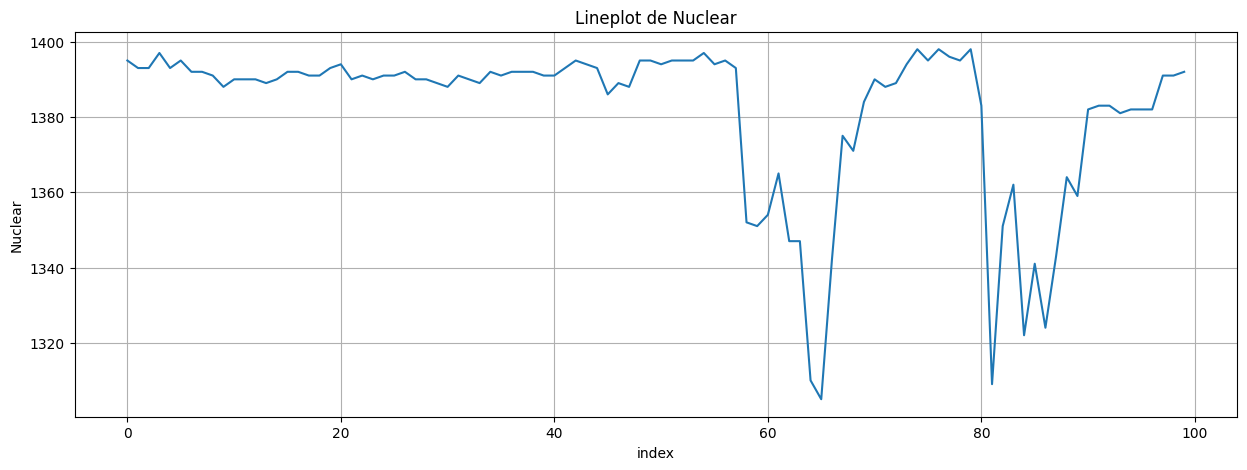

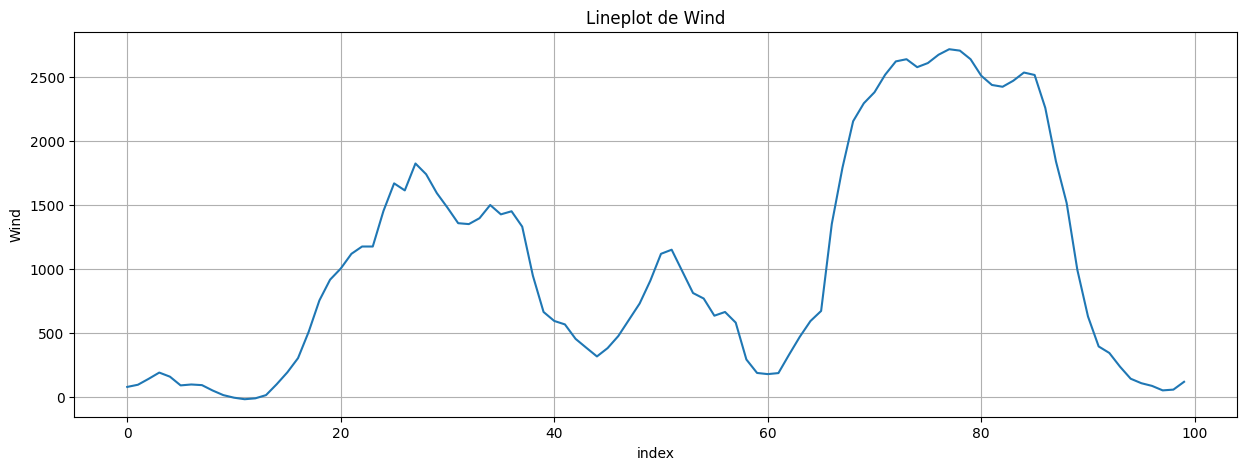

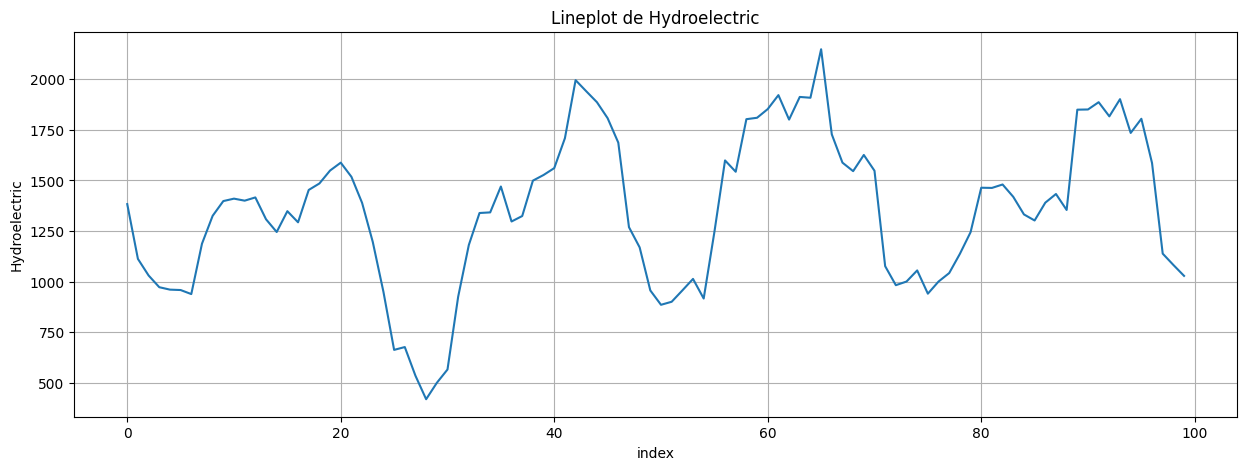

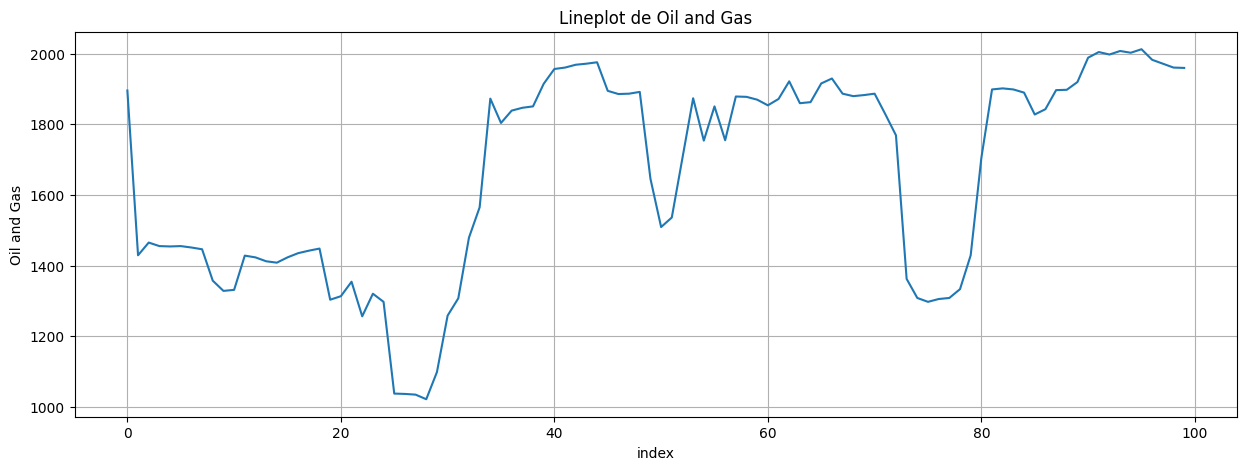

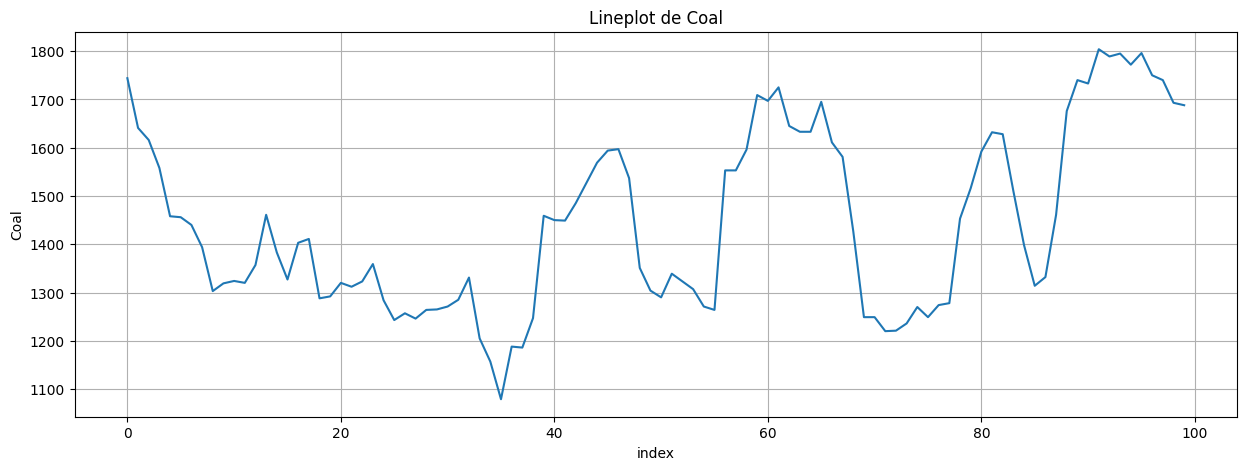

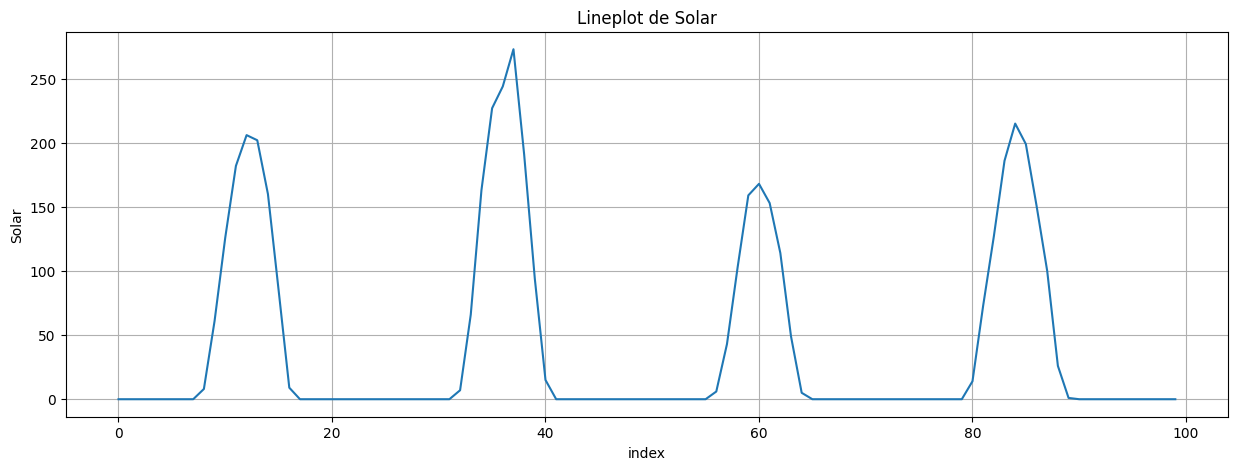

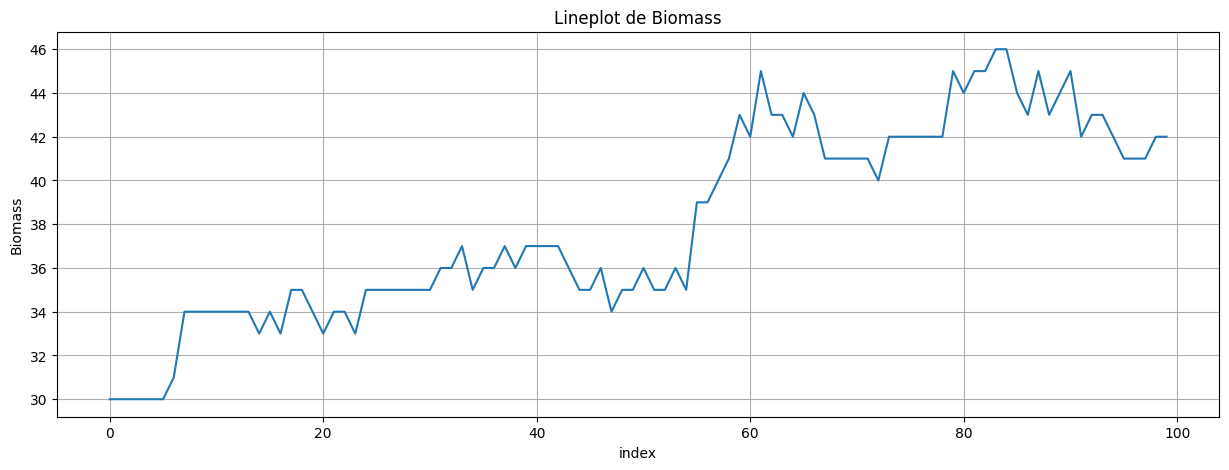

In [41]:
subset=df_copy.iloc[:100]   # 100 first hours
for col in subset:
    if col == "DateTime":
        continue
    plt.figure(figsize=(15,5))
    sns.lineplot(data=subset, x=subset.index, y=col)
    plt.title(f"Lineplot de {col}")
    plt.grid(True)
    plt.xlabel("index")
    plt.show()

### Num

Index(['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric',
       'Oil and Gas', 'Coal', 'Solar', 'Biomass'],
      dtype='object')


<Axes: >

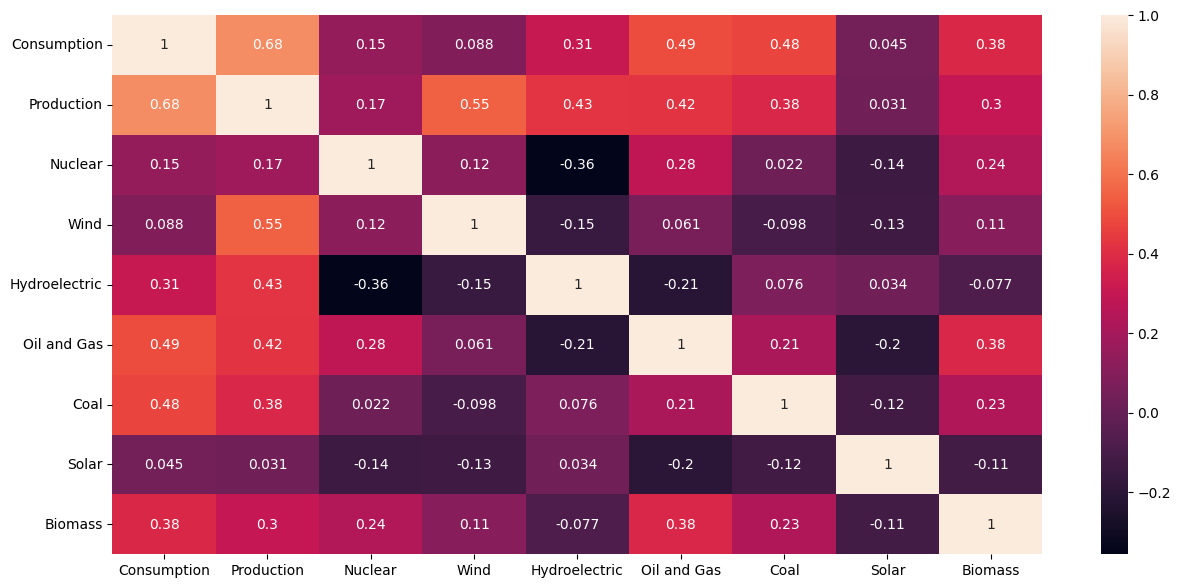

In [ ]:

# --- num data : 
df_num=df.select_dtypes(include=np.number)
print(df_num.columns)

# --- Correlation : 
plt.figure(figsize=(15,7))
sns.heatmap(df_num.corr(), annot=True)


### Normalisation